In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
file_path = r"C:\Users\user\OneDrive\Desktop\ZAALIMA PROJECT\CUSTOMER CHURN PREDICTION LTV ENGINE\data\processed\telco_churn_day6_analysis.csv"
df = pd.read_csv(file_path)

In [3]:
encoded_df = df.copy()

In [4]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

In [5]:
for column in encoded_df.columns:
    
    if encoded_df[column].dtype == 'object':
        
        encoded_df[column] = le.fit_transform(
            encoded_df[column].astype(str)
        )

In [7]:
encoded_df.to_csv(
    r"C:\Users\user\OneDrive\Desktop\ZAALIMA PROJECT\CUSTOMER CHURN PREDICTION LTV ENGINE\models\artifacts\day7_encoded_dataset.csv",
    index=False
)

In [11]:
from sklearn.preprocessing import LabelEncoder

# Create copy
encoded_df = df.copy()

# Remove customerID
encoded_df.drop('customerID', axis=1, inplace=True)

# Initialize encoder
le = LabelEncoder()

# Encode categorical columns
for column in encoded_df.columns:
    
    if encoded_df[column].dtype == 'object' or encoded_df[column].dtype == 'str':
        
        encoded_df[column] = le.fit_transform(
            encoded_df[column].astype(str)
        )

# Convert remaining string columns if any
encoded_df = encoded_df.apply(
    lambda col: le.fit_transform(col.astype(str))
    if col.dtype == 'object' or col.dtype == 'str'
    else col
)

# Check datatypes
print(encoded_df.dtypes)

# Correlation matrix
correlation_matrix = encoded_df.corr()

correlation_matrix

gender                int64
SeniorCitizen         int64
Partner               int64
Dependents            int64
tenure                int64
PhoneService          int64
MultipleLines         int64
InternetService       int64
OnlineSecurity        int64
OnlineBackup          int64
DeviceProtection      int64
TechSupport           int64
StreamingTV           int64
StreamingMovies       int64
Contract              int64
PaperlessBilling      int64
PaymentMethod         int64
MonthlyCharges      float64
TotalCharges        float64
Churn                 int64
dtype: object


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
gender,1.000000,-0.001874,-0.001808,0.010517,0.005106,-0.006488,-0.006739,-0.000863,-0.015017,-0.012057,0.000549,-0.006825,-0.006421,-0.008743,0.000126,-0.011754,0.017352,-0.014569,0.000048,-0.008612
SeniorCitizen,-0.001874,1.000000,0.016479,-0.211185,0.016567,0.008576,0.146185,-0.032310,-0.128221,-0.013632,-0.021398,-0.151268,0.030776,0.047266,-0.142554,0.156530,-0.038551,0.220173,0.102411,0.150889
Partner,-0.001808,0.016479,1.000000,0.452676,0.379697,0.017706,0.142410,0.000891,0.150828,0.153130,0.166330,0.126733,0.137341,0.129574,0.294806,-0.014877,-0.154798,0.096848,0.319072,-0.150448
Dependents,0.010517,-0.211185,0.452676,1.000000,0.159712,-0.001762,-0.024991,0.044590,0.152166,0.091015,0.080537,0.133524,0.046885,0.021321,0.243187,-0.111377,-0.040292,-0.113890,0.064653,-0.164221
tenure,0.005106,0.016567,0.379697,0.159712,1.000000,0.008448,0.343032,-0.030359,0.325468,0.370876,0.371105,0.322942,0.289373,0.296866,0.671607,0.006152,-0.370436,0.247900,0.825880,-0.352229
PhoneService,-0.006488,0.008576,0.017706,-0.001762,0.008448,1.000000,-0.020538,0.387436,-0.015198,0.024105,0.003727,-0.019158,0.055353,0.043870,0.002247,0.016505,-0.004184,0.247398,0.113008,0.011942
MultipleLines,-0.006739,0.146185,0.142410,-0.024991,0.343032,-0.020538,1.000000,-0.109216,0.007141,0.117327,0.122318,0.011466,0.175059,0.180957,0.110842,0.165146,-0.176793,0.433576,0.453202,0.038037
InternetService,-0.000863,-0.032310,0.000891,0.044590,-0.030359,0.387436,-0.109216,1.000000,-0.028416,0.036138,0.044944,-0.026047,0.107417,0.098350,0.099721,-0.138625,0.086140,-0.323260,-0.175691,-0.047291
OnlineSecurity,-0.015017,-0.128221,0.150828,0.152166,0.325468,-0.015198,0.007141,-0.028416,1.000000,0.185126,0.175985,0.285028,0.044669,0.055954,0.374416,-0.157641,-0.096726,-0.053878,0.254473,-0.289309
OnlineBackup,-0.012057,-0.013632,0.153130,0.091015,0.370876,0.024105,0.117327,0.036138,0.185126,1.000000,0.187757,0.195748,0.147186,0.136722,0.280980,-0.013370,-0.124847,0.119777,0.375556,-0.195525


The error occurred because correlation analysis only works with numeric values, but several columns like gender, Partner, and Churn still contained string/text data.
Although encoding was attempted earlier, the columns had str datatype instead of object, so they were skipped during conversion.

To fix this, all remaining categorical/string columns were forcefully encoded using LabelEncoder, converting text values into numeric form.
After converting every non-numeric column, the correlation matrix was successfully generated without datatype conversion errors.

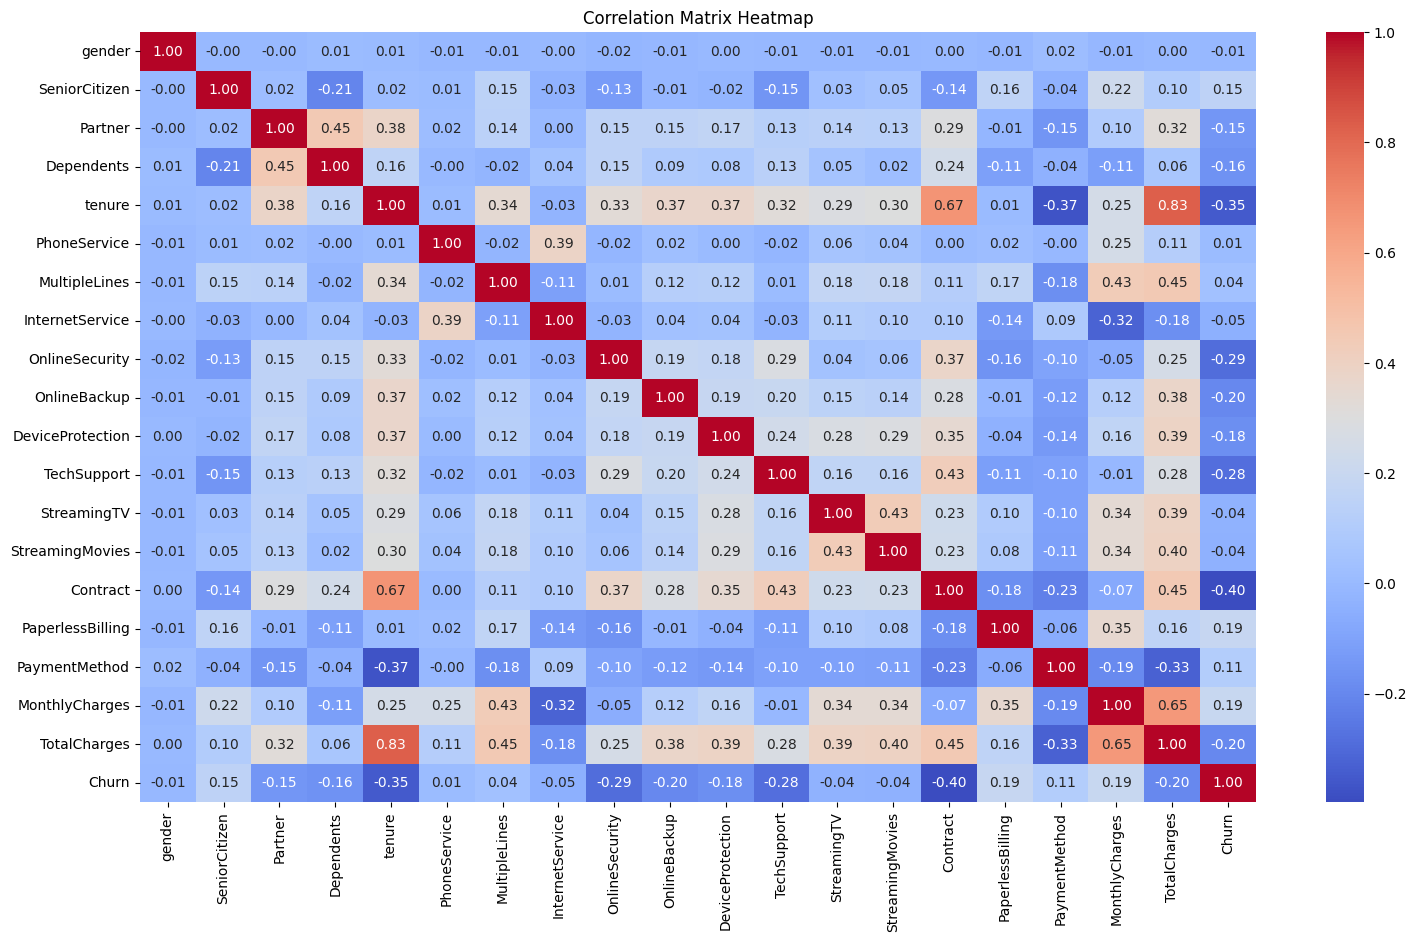

In [12]:
plt.figure(figsize=(18,10))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Matrix Heatmap")

plt.show()

In [13]:
churn_corr = correlation_matrix['Churn'].sort_values(ascending=False)

churn_corr

Churn               1.000000
MonthlyCharges      0.193356
PaperlessBilling    0.191825
SeniorCitizen       0.150889
PaymentMethod       0.107062
MultipleLines       0.038037
PhoneService        0.011942
gender             -0.008612
StreamingTV        -0.036581
StreamingMovies    -0.038492
InternetService    -0.047291
Partner            -0.150448
Dependents         -0.164221
DeviceProtection   -0.178134
OnlineBackup       -0.195525
TotalCharges       -0.199484
TechSupport        -0.282492
OnlineSecurity     -0.289309
tenure             -0.352229
Contract           -0.396713
Name: Churn, dtype: float64

In [14]:
strong_drivers = churn_corr[
    (churn_corr > 0.3) | (churn_corr < -0.3)
]

strong_drivers

Churn       1.000000
tenure     -0.352229
Contract   -0.396713
Name: Churn, dtype: float64

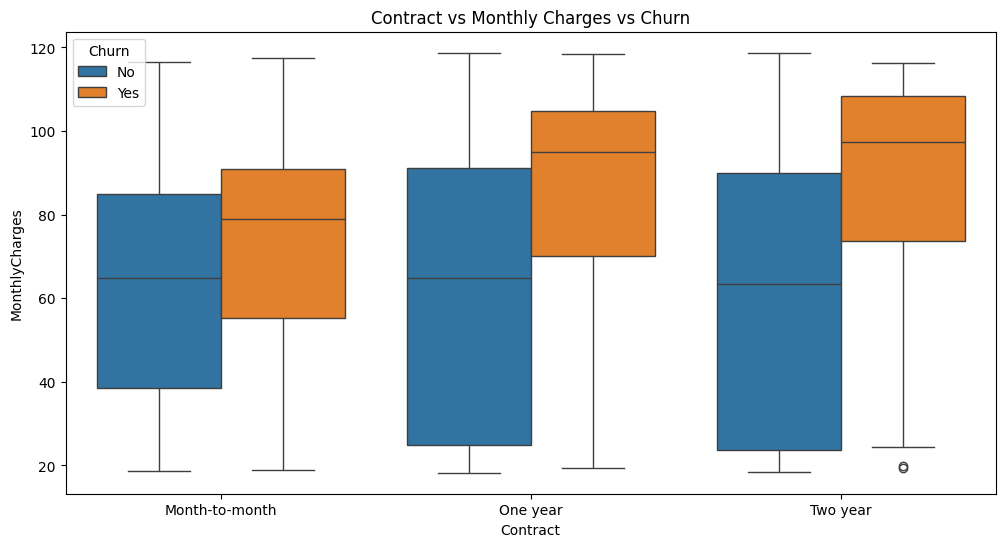

In [ ]:
#ADVANCED (VISULISATIONS)

plt.figure(figsize=(12,6))

sns.boxplot(
    x='Contract',
    y='MonthlyCharges',
    hue='Churn',
    data=df
)

plt.title("Contract vs Monthly Charges vs Churn")

plt.show()

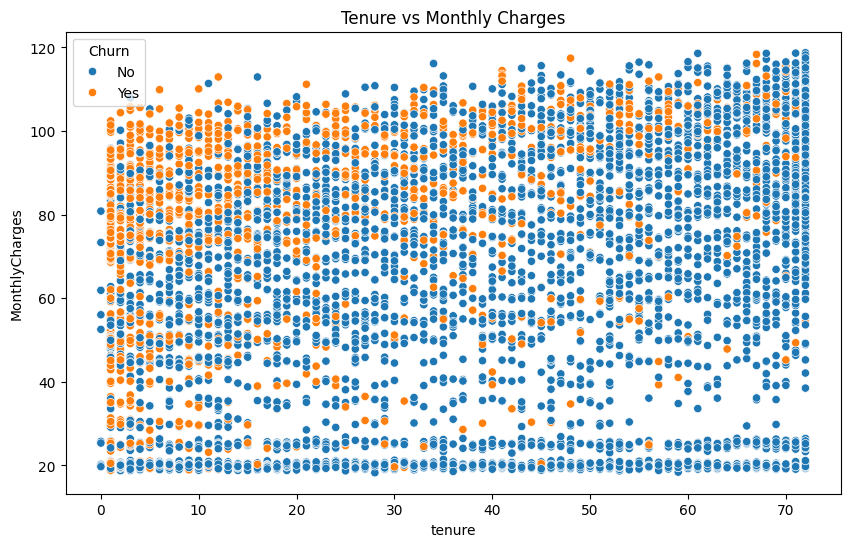

In [21]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='tenure',
    y='MonthlyCharges',
    hue='Churn',
    data=df
)

plt.title("Tenure vs Monthly Charges")

plt.show()

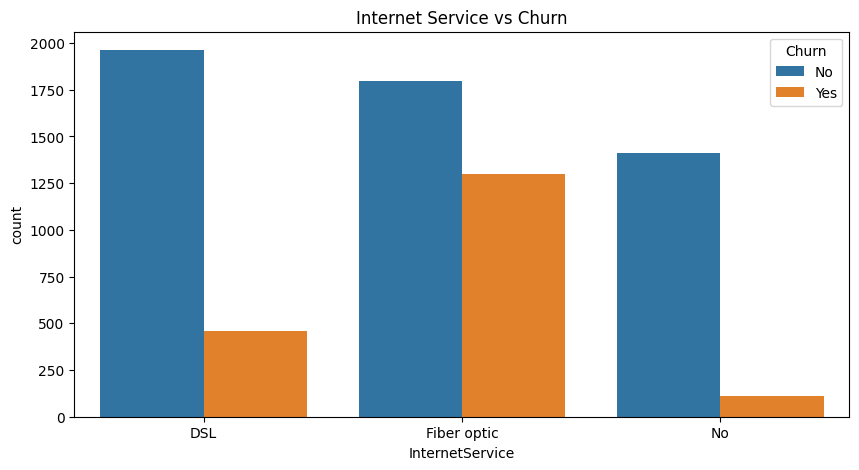

In [17]:
plt.figure(figsize=(10,5))

sns.countplot(
    x='InternetService',
    hue='Churn',
    data=df
)

plt.title("Internet Service vs Churn")

plt.show()

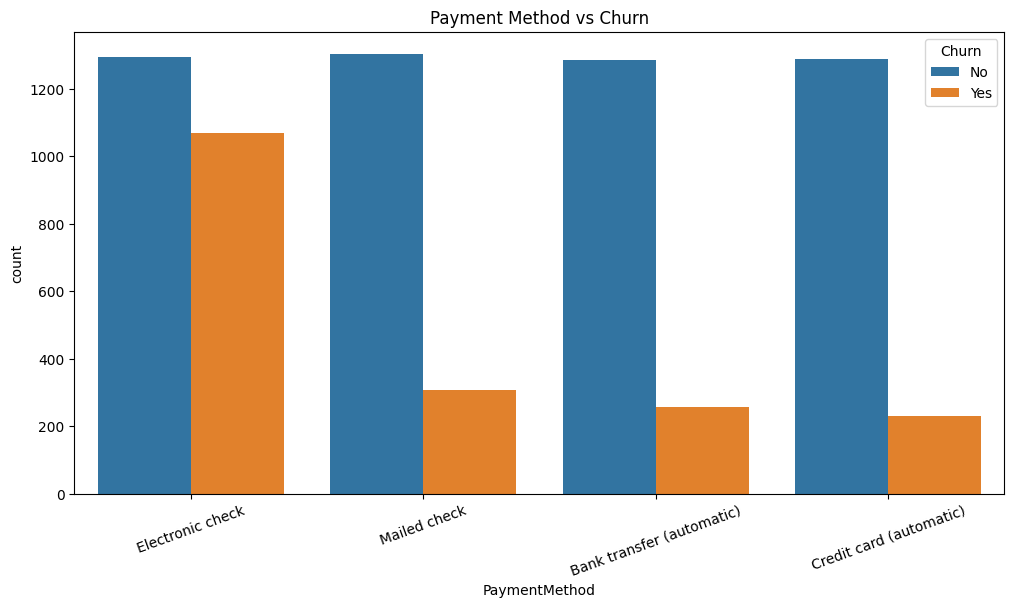

In [18]:
plt.figure(figsize=(12,6))

sns.countplot(
    x='PaymentMethod',
    hue='Churn',
    data=df
)

plt.xticks(rotation=20)

plt.title("Payment Method vs Churn")

plt.show()

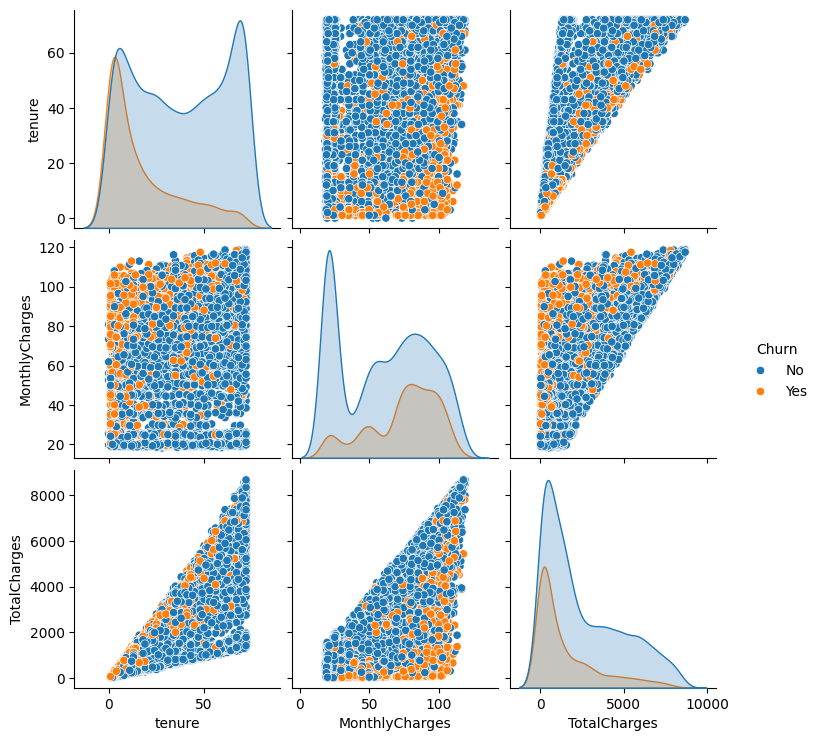

In [19]:
sns.pairplot(
    df,
    vars=['tenure', 'MonthlyCharges', 'TotalCharges'],
    hue='Churn'
)

plt.show()

In [22]:
df.to_csv(
    r"C:\Users\user\OneDrive\Desktop\ZAALIMA PROJECT\CUSTOMER CHURN PREDICTION LTV ENGINE\data\processed\telco_churn_day7_feature_relationships.csv",
    index=False
)

# Key Business Insights

1. Customers with month-to-month contracts show higher churn.

2. Higher monthly charges are associated with increased churn probability.

3. Customers with lower tenure are more likely to churn.

4. Fiber optic internet users appear to churn more frequently.

5. Electronic check payment users have elevated churn behavior.

6. Long-term contract customers are comparatively stable.